First, I import the libraries needed for the analysis. 
NumPy and pandas are used for handling and working with the data, 
while matplotlib is used to create visualisations.

I also import DstApi, which allows me to retrieve data directly from Statistics Denmark.

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dstapi import DstApi

Accessing the data from Statistics Denmark

In [219]:
IFOR41 = DstApi('IFOR41')

Exploring the available variables.

In [220]:
IFOR41.variable_levels('ULLIG', language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


Before selecting the data, we examine the available values for the municipality variable. Since the analysis is for all of Denmark we wil filter this out later, so it is not for individual municipalities

In [221]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


Here, we define which data we want to retrieve from Statistics Denmark. we select the Gini coefficient for all of Denmark and all available years.

In [222]:
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

We now retrieve the selected data and display the first rows to check that it was downloaded correctly.

In [223]:
gini = IFOR41.get_data(params=params)

gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


The below cell gives us an overview of the gini

In [224]:
gini.describe()

,TID
count,38.000000
mean,2005.500000
std,11.113055
min,1987.000000
25%,1996.250000
50%,2005.500000
75%,2014.750000
max,2024.000000


Cleaning the data by changing the gini to a float

In [225]:
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

Further clean up of the data by removing unnecessary columns and renaming the remaining ones for clarity.

In [226]:
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

Overview

In [227]:
gini.head()

,year,gini
0,2016,28.97
1,1999,23.83
2,1988,22.06
3,2015,28.77
4,1989,21.93


We can see that the years is not sorted, so we will sort the years in ascending order.

In [228]:
gini = gini.sort_values('year')

Checking

In [229]:
gini.head()

,year,gini
16,1987,22.07
2,1988,22.06
4,1989,21.93
30,1990,22.16
25,1991,21.99


The data is now as we wished with the wears in ascending order and we can now make a figure showing us the gini coefficient in Denmark over time. We have that gini is the name of our dataframe.

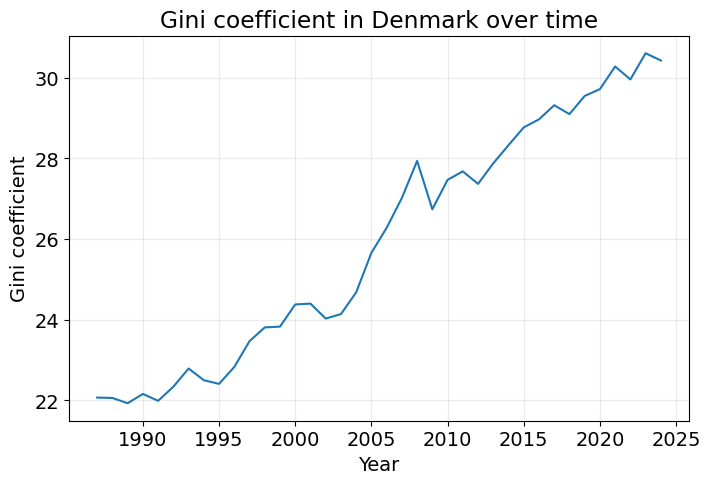

In [230]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gini['year'], gini['gini'])

ax.set_title('Gini coefficient in Denmark over time')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

plt.show()

We now move on the second part of question 1.1. We wish to see the share of income going to the richest 10 percent.

We make a connection to IFOR32, and have from the begining of this notebook already downloadet the necessary stuff.

In [231]:
IFOR32 = DstApi('IFOR32')

Here we get an overview of the table, and set the language to english

In [232]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [233]:
IFOR32.variable_levels('DECILGEN', language='en')

,id,text
0,1DC,First decil
1,2DC,Second decil
2,3DC,Third decil
3,4DC,Fourth decil
4,5DC,Fifth decil
5,6DC,Sixth decil
6,7DC,Seventh decil
7,8DC,Eigth decil
8,9DC,Ninth decil
9,10DC,Tenth decil


We now specify the data we want from IFOR32. We select all ten income deciles, all years, and All Denmark.

In [234]:


params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

income = IFOR32.get_data(params=params)

income.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [235]:
#Makes the dataset ready

income['INDHOLD'] = income['INDHOLD'].astype(float)

income = income.drop(columns=['KOMMUNEDK'])

income = income.rename(columns={
    'DECILGEN': 'decil',
    'TID': 'year',
    'INDHOLD': 'income'
})

income.head()

,decil,year,income
0,First decil,2013,75704.0
1,Second decil,2013,140049.0
2,Third decil,2013,163582.0
3,Fourth decil,2013,185931.0
4,Fifth decil,2013,209384.0


In [236]:
# Makes the decils to numbers from 1 to 10

decil_map = {
    'First decil': 1,
    'Second decil': 2,
    'Third decil': 3,
    'Fourth decil': 4,
    'Fifth decil': 5,
    'Sixth decil': 6,
    'Seventh decil': 7,
    'Eighth decil': 8,
    'Ninth decil': 9,
    'Tenth decil': 10
}

income['decil'] = income['decil'].map(decil_map)

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0
267,NaN,1987,110184.0


In [237]:
# Fixing the missing 8th decil

income.loc[income['decil'].isna(), 'decil'] = 8

income = income.sort_values(['year', 'decil'])

income.head(10)

,decil,year,income
260,1.0,1987,31418.0
261,2.0,1987,59014.0
262,3.0,1987,68786.0
263,4.0,1987,77577.0
264,5.0,1987,85361.0
265,6.0,1987,92777.0
266,7.0,1987,100691.0
267,8.0,1987,110184.0
268,9.0,1987,123582.0
269,10.0,1987,169598.0


The data have now been cleaned, and is ready for an analysis

In [238]:

income.groupby('decil')['income'].mean()

decil
1.0      63079.421053
2.0     115863.105263
3.0     135364.131579
4.0     153987.868421
5.0     172573.789474
6.0     191304.500000
7.0     211895.736842
8.0     237253.973684
9.0     274808.763158
10.0    443505.631579
Name: income, dtype: float64

Will now make a figure over the development of the decil groups over the years.

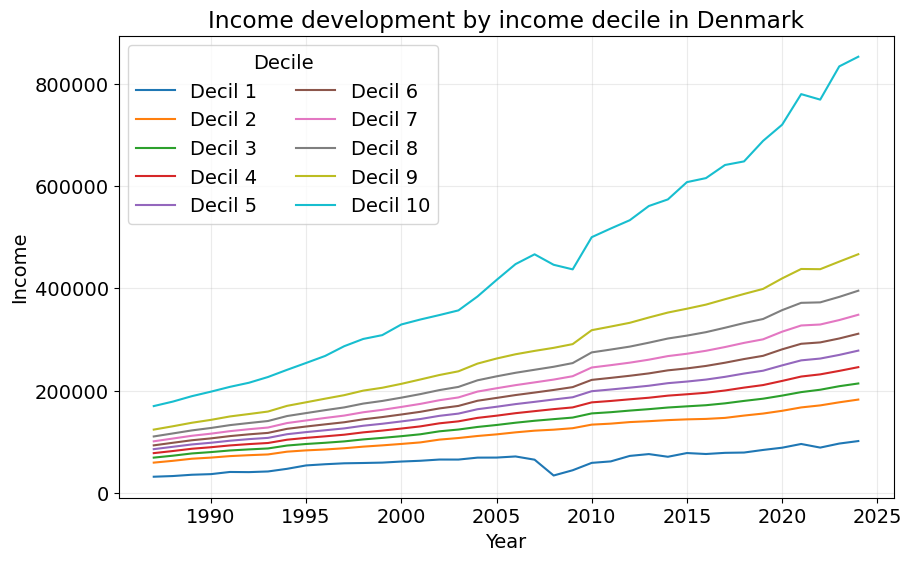

In [239]:
fig, ax = plt.subplots(figsize=(10, 6))

for decil in range(1, 11):
    data = income[income['decil'] == decil]
    ax.plot(data['year'], data['income'], label=f'Decil {decil}')

ax.set_title('Income development by income decile in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income')
ax.legend(title='Decile', ncol=2)

plt.show()

Will now make a further analysis to see the share of total income going to the richest 10%.

In [240]:
top10 = income[income['decil'] == 10].copy()

total_income = income.groupby('year')['income'].sum()

top10['top10_share'] = top10['income'] / top10['year'].map(total_income)

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,0.184549
117,10.0,1988,178357.0,0.184289
349,10.0,1989,188967.0,0.184952
189,10.0,1990,197793.0,0.186415
179,10.0,1991,207208.0,0.186683


Makes it into percent

In [241]:
top10['top10_share'] = top10['top10_share'] * 100

top10.head()

,decil,year,income,top10_share
269,10.0,1987,169598.0,18.454866
117,10.0,1988,178357.0,18.428870
349,10.0,1989,188967.0,18.495170
189,10.0,1990,197793.0,18.641480
179,10.0,1991,207208.0,18.668346


Plot the share of total income received by the richest 10% over time.

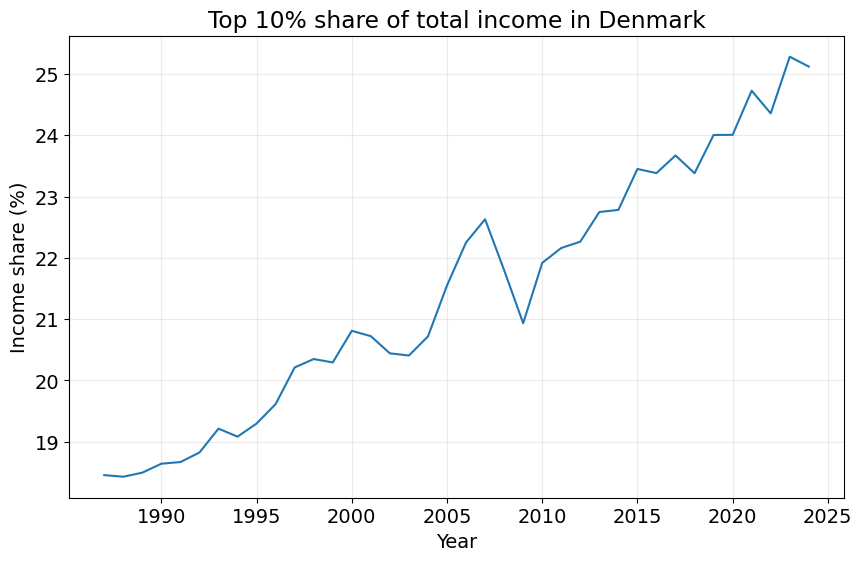

In [242]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(top10['year'], top10['top10_share'])

ax.set_title('Top 10% share of total income in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Income share (%)')

plt.show()

Computes the correlation of our two results 

In [243]:
analysis = pd.merge(
    gini[['year', 'gini']],
    top10[['year', 'top10_share']],
    on='year',
    validate='1:1'
)

analysis['top10_share'] = analysis['top10_share'] * 100

analysis.corr()

,year,gini,top10_share
year,1.000000,0.985228,0.982948
gini,0.985228,1.000000,0.981642
top10_share,0.982948,0.981642,1.000000


The two measures tell a very similar story about inequality in Denmark. Both measures show an overall increase in inequality since 1987, although there are some fluctuations over time. We can see that the correlation between them is 0.981642, which is very close to a perfect correlation of 1.

# 1.2

We will now begin on 1.2, first of all we see that t is set as years which we would want to change

In [244]:
gini['t'] = gini['year'] - 1987
gini.head()

,year,gini,t
16,1987,22.07,0
2,1988,22.06,1
4,1989,21.93,2
30,1990,22.16,3
25,1991,21.99,4


We will now start to build the function required for the linear trend.

In [245]:
def objective(beta):
    beta0, beta1 = beta
    prediction = beta0 + beta1 * gini['t']
    return ((gini['gini'] - prediction) ** 2).sum()

Uses the minimize function to find the optimal parameters for the linear regression model. 20 and 0 is start guesses.

In [246]:
from scipy.optimize import minimize

result = minimize(objective, [20, 0])
result.x

array([21.04275317,  0.26354961])

So the linear trend is Gini=21,04+0,26t

We have then found the optimal parameters for our linear regression model. The first parameter (beta0) represents the intercept, while the second parameter (beta1) represents the slope of the line.

In [247]:
import numpy as np

np.polyfit(gini['t'], gini['gini'], 1)

array([ 0.26354962, 21.04275304])

We then see, cheking the answers agains np.polyfit, that it is very similar and the minimazation worked

We will now move on and make the quadratic function. We will follow the same approach as before.

In [248]:
def objective_quad(beta):
    beta0, beta1, beta2 = beta
    prediction = beta0 + beta1 * gini['t'] + beta2 * gini['t']**2
    return ((gini['gini'] - prediction) ** 2).sum()

In [249]:
result_quad = minimize(objective_quad, [20, 0, 0])
result_quad.x

array([2.13041684e+01, 2.19980235e-01, 1.17754900e-03])

In [250]:
np.polyfit(gini['t'], gini['gini'], 2)

array([1.17769085e-03, 2.19975061e-01, 2.13042004e+01])

Again we see that the numbers fit the ones from the quadratic formula. We will now use our estimates to predict the gini coefficient.

In [251]:
years = np.array([2030, 2040])
t = years - 1987

linear_pred = result.x[0] + result.x[1] * t
quad_pred = result_quad.x[0] + result_quad.x[1] * t + result_quad.x[2] * t**2

print(pd.DataFrame({
    'Year': years,
    'Linear prediction': linear_pred,
    'Quadratic prediction': quad_pred
}))

   Year  Linear prediction  Quadratic prediction
0  2030          32.375387             32.940607
1  2040          35.010883             36.270856


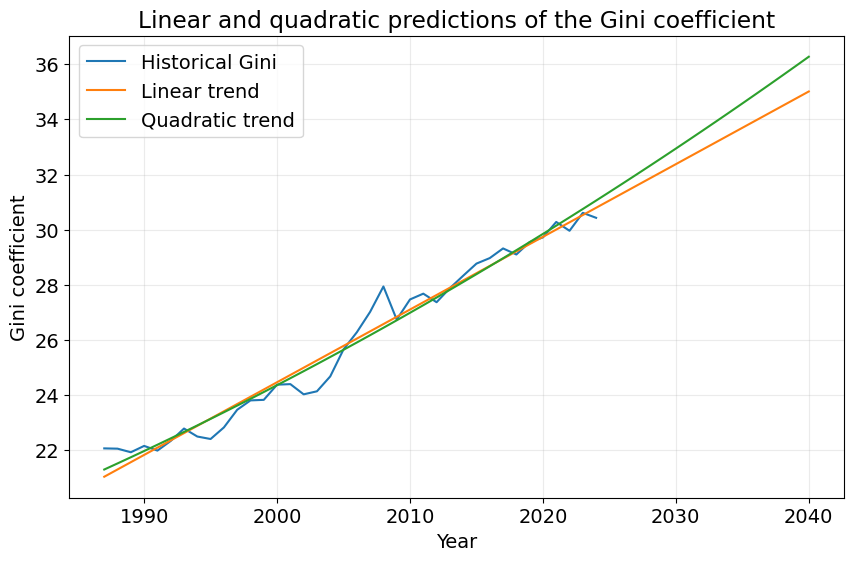

In [252]:
t_plot = np.arange(gini['t'].min(), 54)

plt.figure(figsize=(10, 6))
plt.plot(gini['year'], gini['gini'], label='Historical Gini')
plt.plot(t_plot + 1987, result.x[0] + result.x[1] * t_plot, label='Linear trend')
plt.plot(t_plot + 1987, result_quad.x[0] + result_quad.x[1] * t_plot + result_quad.x[2] * t_plot**2, label='Quadratic trend')

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Linear and quadratic predictions of the Gini coefficient')
plt.legend()
plt.show()


Both models follow the overall upward trend in the historical Gini coefficient.

The linear model predicts 32.38 in 2030 and 35.01 in 2040, while the quadratic model predicts 32.94 and 36.27. The difference therefore increases over time.
It is seen in the figure that quadratic trend overall follows the historical gini a bit closer than the linear trend. It is however hard to trust any of the trends, due to the fact that it is a prediction where it is impossible to predict socioeconomic and political interference.

# 1.3

We now move on to the municipality level. We will examine the relationship between the Gini coefficient and the top 10 percent income share across municipalities. We use the same data as we did in 1.1.

starts of by finding the name, and id for all municipalities in Denmark

In [253]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [254]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


Now we can download the correct data from the parameters

In [255]:
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

gini_municipal = IFOR41.get_data(params=params)

gini_municipal.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


We will now fetch the data top 10% share of total income for all municipalities in Denmark. This will allow us to analyze the relationship between the Gini coefficient and the top 10% share of total income at the municipal level.

In [256]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [257]:
IFOR32.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


In [258]:
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

income_municipal = IFOR32.get_data(params=params)

income_municipal.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942


We don't have the top 10% share yet, but just the average for every decil. we need to calculate this, but beforehand we wil sort the data and rename the column names.

In [259]:
income_municipal['INDHOLD'] = income_municipal['INDHOLD'].astype(float)

income_municipal = income_municipal.rename(columns={
    'DECILGEN': 'decil',
    'TID': 'year',
    'INDHOLD': 'income'
})

income_municipal.head()

,decil,KOMMUNEDK,year,income
0,Second decil,Odense,2013,123841.0
1,Third decil,Odense,2013,150153.0
2,Fourth decil,Odense,2013,170790.0
3,Fifth decil,Odense,2013,193979.0
4,Sixth decil,Odense,2013,218942.0


In [260]:
income_municipal = income_municipal.sort_values(
    ['KOMMUNEDK', 'year', 'decil']
)

income_municipal.head()

,decil,KOMMUNEDK,year,income
25931,Eigth decil,Aabenraa,1987,103934.0
25928,Fifth decil,Aabenraa,1987,81428.0
25924,First decil,Aabenraa,1987,32392.0
25927,Fourth decil,Aabenraa,1987,74363.0
25932,Ninth decil,Aabenraa,1987,116181.0


Now we can calculate the top 10% share of income for each municipality and year. We will first filter the data for the 10th decile, then calculate the total income for each municipality and year.

In [261]:
income_pivot = income_municipal.pivot_table(
    index=['KOMMUNEDK', 'year'],
    columns='decil',
    values='income'
)

income_pivot.head()

decil           Eigth decil  Fifth decil  First decil  Fourth decil  \
KOMMUNEDK year                                                        
Aabenraa  1987     103934.0      81428.0      32392.0       74363.0   
          1988     110066.0      86487.0      31358.0       79074.0   
          1989     116132.0      91194.0      37616.0       83690.0   
          1990     119875.0      94380.0      39725.0       86581.0   
          1991     126194.0      98704.0      45258.0       90363.0   

decil           Ninth decil  Second decil  Seventh decil  Sixth decil  \
KOMMUNEDK year                                                          
Aabenraa  1987     116181.0       57606.0        95331.0      88112.0   
          1988     123171.0       61598.0       101235.0      93664.0   
          1989     129661.0       66146.0       106459.0      98557.0   
          1990     134453.0       68009.0       110088.0     101877.0   
          1991     142039.0       71517.0       115550.0     106954.0   

decil           Tenth decil  Third decil  
KOMMUNEDK year                            
Aabenraa  1987     160791.0      66307.0  
          1988     169217.0      70739.0  
          1989     178127.0      75469.0  
          1990     186215.0      77905.0  
          1991     200033.0      81565.0

In [262]:
income_pivot['top10_share'] = (
    income_pivot['Tenth decil'] /
    income_pivot.sum(axis=1)
)

income_pivot[['top10_share']].head()

decil           top10_share
KOMMUNEDK year             
Aabenraa  1987     0.183458
          1988     0.182620
          1989     0.181198
          1990     0.182724
          1991     0.185529

Now we will look at correlation between the Gini coefficient and the top 10% share of income for each municipality. We will merge the two datasets and calculate the correlation.

In [263]:
gini_municipal = gini_municipal.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

In [264]:
municipal_data = pd.merge(
    gini_municipal,
    income_pivot[['top10_share']].reset_index(),
    on=['KOMMUNEDK', 'year']
)

municipal_data.head()

,ULLIG,KOMMUNEDK,year,gini,top10_share
0,Gini coefficient,All Denmark,2016,28.97,0.233832
1,Gini coefficient,Copenhagen,2016,33.24,0.249130
2,Gini coefficient,Frederiksberg,2016,34.85,0.267226
3,Gini coefficient,Ballerup,2016,25.77,0.205321
4,Gini coefficient,Brøndby,2016,25.71,0.205802


In [265]:
correlation = municipal_data['gini'].corr(
    municipal_data['top10_share']
)

print(f"Correlation between Gini coefficient and top 10% income share across municipalities is: {correlation:.4f}")

Correlation between Gini coefficient and top 10% income share across municipalities is: 0.9605


The correlation at the municipal level is 0.9605, compared to 0.981642 for Denmark as a whole. The relationship is therefore slightly weaker at the municipal level, but still very strong. This indicates that municipalities with higher top 10% income shares also tend to have higher Gini coefficients.

In [266]:
latest_year = municipal_data['year'].max()

gini_2024 = municipal_data[
    (municipal_data['year'] == latest_year) &
    (municipal_data['KOMMUNEDK'] != 'All Denmark')
].copy()

gini_2024['gini'] = pd.to_numeric(gini_2024['gini'])

most_unequal = gini_2024.nlargest(10, 'gini')
least_unequal = gini_2024.nsmallest(10, 'gini')

most_unequal[['KOMMUNEDK', 'gini']]

,KOMMUNEDK,gini
3471,Gentofte,49.04
3489,Rudersdal,47.31
3529,Vejen,46.32
3488,Hørsholm,40.07
3478,Lyngby-Taarbæk,39.28
3467,Frederiksberg,36.54
3466,Copenhagen,34.97
3547,Aarhus,33.43
3485,Fredensborg,32.76
3486,Helsingør,30.55


In [267]:
least_unequal[['KOMMUNEDK', 'gini']]

,KOMMUNEDK,gini
3514,Faaborg-Midtfyn,23.77
3490,Egedal,23.85
3511,Bornholm,24.03
3500,Faxe,24.09
3494,Halsnæs,24.41
3541,Favrskov,24.41
3513,Assens,24.46
3550,Hedensted,24.58
3475,Albertslund,24.66
3542,Odder,24.70


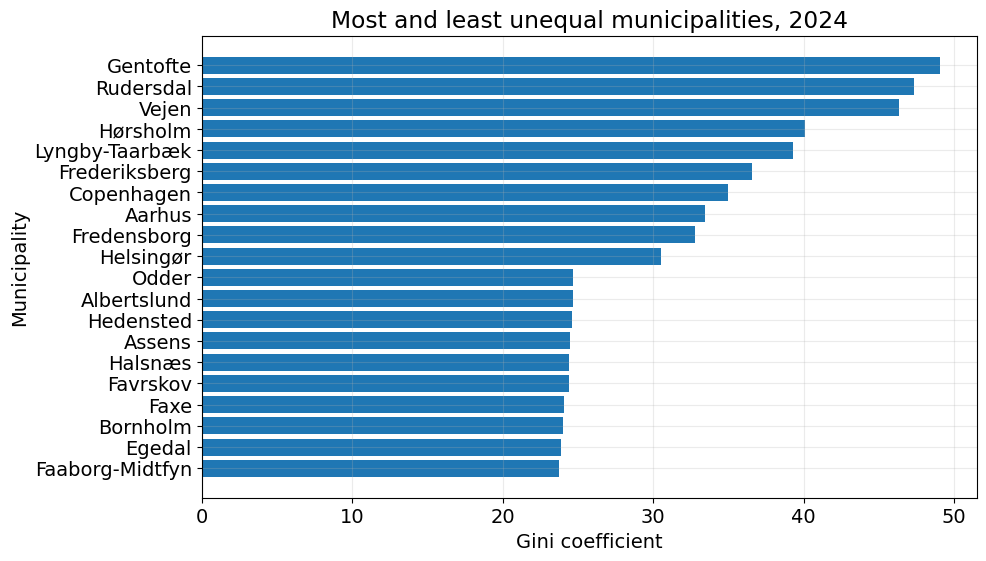

In [268]:
plt.figure(figsize=(10, 6))

data = pd.concat([
    most_unequal[['KOMMUNEDK', 'gini']].assign(group='Most unequal'),
    least_unequal[['KOMMUNEDK', 'gini']].assign(group='Least unequal')
])

data = data.sort_values('gini')

plt.barh(data['KOMMUNEDK'], data['gini'])

plt.xlabel('Gini coefficient')
plt.ylabel('Municipality')
plt.title('Most and least unequal municipalities, 2024')

plt.show()

The most unequal municipalities have substantially higher Gini coefficients than the least unequal municipalities. Gentofte and Rudersdal have the highest values, while Faaborg-Midtfyn and Egedal are among the lowest. Overall, the figure shows a clear difference in inequality across municipalities. It is also worth noticing that there is a substantially larger difference between the 10 most unequal municipalities, while the 10 least unequal municipalities have very similar Gini coefficients.

We will now look at the last part of question 1.3, where will analyze which municipalities have largest and smallest changes in the Gini coefficient.

In [269]:
municipal_data['gini'] = pd.to_numeric(municipal_data['gini'])

gini_change = (
    municipal_data[municipal_data['KOMMUNEDK'] != 'All Denmark']
    .sort_values(['KOMMUNEDK', 'year'])
    .groupby('KOMMUNEDK')
    .agg(
        first_gini=('gini', 'first'),
        last_gini=('gini', 'last')
    )
)

gini_change['change'] = gini_change['last_gini'] - gini_change['first_gini']

gini_change.sort_values('change', ascending=False).head(10)

,first_gini,last_gini,change
KOMMUNEDK,,,
Vejen,21.20,46.32,25.12
Rudersdal,29.05,47.31,18.26
Gentofte,31.10,49.04,17.94
Lyngby-Taarbæk,24.97,39.28,14.31
Copenhagen,23.05,34.97,11.92
Hørsholm,28.39,40.07,11.68
Fredensborg,21.17,32.76,11.59
Aarhus,22.10,33.43,11.33
Frederiksberg,25.28,36.54,11.26


In [270]:
gini_change.sort_values('change').head(10)

,first_gini,last_gini,change
KOMMUNEDK,,,
Fanø,25.67,26.34,0.67
Ærø,24.63,26.98,2.35
Faxe,21.64,24.09,2.45
Læsø,22.81,25.41,2.60
Bornholm,21.31,24.03,2.72
Faaborg-Midtfyn,20.88,23.77,2.89
Sorø,22.24,25.16,2.92
Stevns,21.35,24.77,3.42
Mariagerfjord,22.31,25.98,3.67


To illustrate this we can create a bar chart showing the change in Gini coefficient for the top 10 municipalities with the largest increase and the 10 municipalities with the smallest change

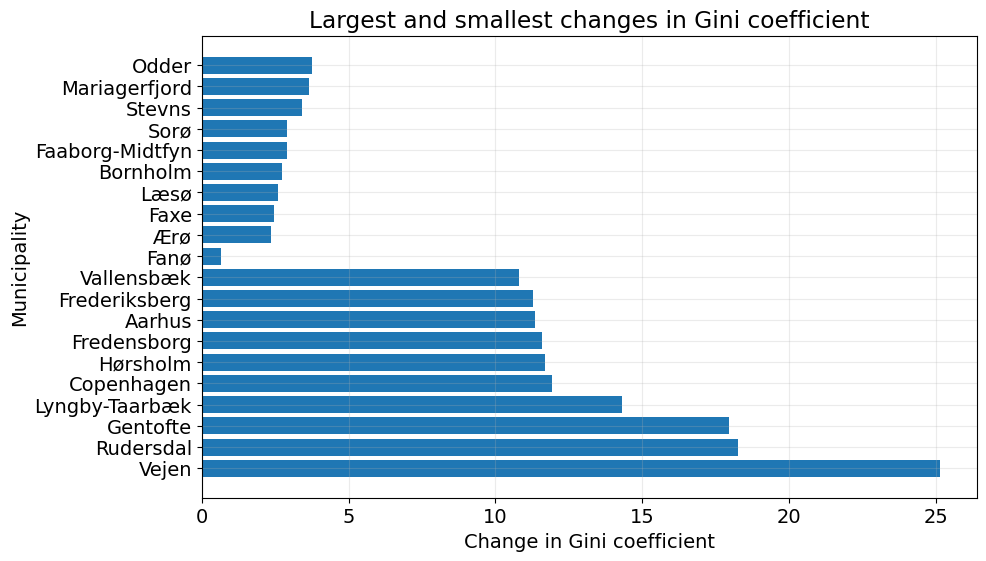

In [271]:
data = pd.concat([
    gini_change.sort_values('change', ascending=False).head(10),
    gini_change.sort_values('change').head(10)
])

plt.figure(figsize=(10, 6))
plt.barh(data.index, data['change'])
plt.xlabel('Change in Gini coefficient')
plt.ylabel('Municipality')
plt.title('Largest and smallest changes in Gini coefficient')
plt.show()

It is shown in the above bar chart that Fanø by have had the smallest change in Gini coefficient at about 1. On the other hand Vejen has had the largest change in Gini at about 25. In general it seems like the one with the largest changes is either larger cities, or cities/municipalities witch are quite rich. On the other hand the municipalities with smallest changes is dominated by small municipality and islands. 

# 1.4

For 1.4, we want to compare housing prices across different municipalities with the level of the Gini coefficient. To do this, we first access Statistics Denmark and find data on the realized sales price of parcel and row houses. We then download the data as an Excel file and open it in VS Code. The data is from 2024.

In [272]:
housing = pd.read_excel("Bilag boligpriser.xlsx")
housing.head()

,"Ejendomspriser på boligmarkedet efter priser på realiserede handler, ejendomskategori, område og tid",Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Enhed: Kr. pr. m2,NaN,NaN,NaN
1,NaN,NaN,NaN,2024K4
2,Realiseret handelspris,Parcel-/rækkehus,København,54134
3,NaN,NaN,Frederiksberg,79799
4,NaN,NaN,Dragør,36299


We then sort the data and makes it ready for merching

In [273]:
housing = housing.iloc[2:, [2, 3]]
housing.columns = ['KOMMUNEDK', 'housing_price']

housing.head()

,KOMMUNEDK,housing_price
2,København,54134
3,Frederiksberg,79799
4,Dragør,36299
5,Tårnby,35794
6,Albertslund,26799


In [274]:
housing['housing_price'] = pd.to_numeric(
    housing['housing_price'],
    errors='coerce'
)

In [275]:
latest_year = municipal_data['year'].max()

gini_latest = municipal_data[
    (municipal_data['year'] == latest_year) &
    (municipal_data['KOMMUNEDK'] != 'All Denmark')
]

gini_latest = gini_latest[['KOMMUNEDK', 'gini']]

In [276]:
housing_gini = pd.merge(
    gini_latest,
    housing,
    on='KOMMUNEDK',
    how='inner'
)

housing_gini.head()

,KOMMUNEDK,gini,housing_price
0,Frederiksberg,36.54,79799.0
1,Ballerup,26.72,29746.0
2,Brøndby,26.16,29431.0
3,Dragør,28.86,36299.0
4,Gentofte,49.04,63441.0


After having merged the datasets, we can now calculate the correlation between housing prices and Gini coefficient across municipalities.

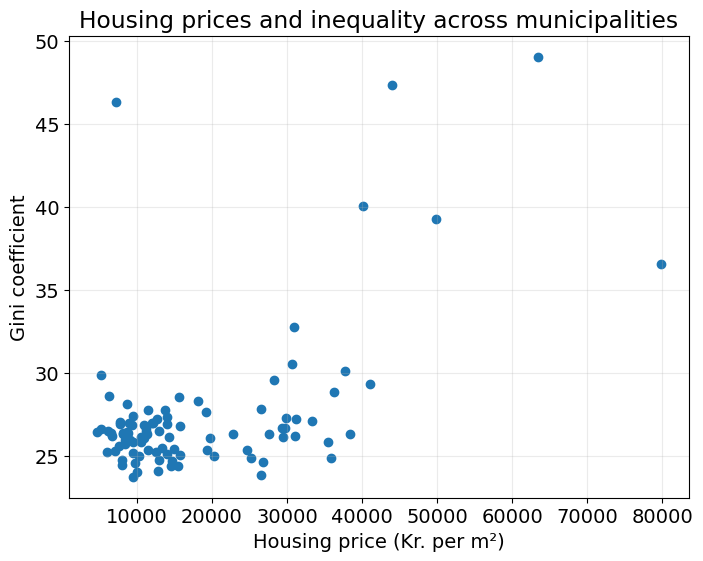

In [277]:
plt.figure(figsize=(8, 6))

plt.scatter(
    housing_gini['housing_price'],
    housing_gini['gini']
)

plt.xlabel('Housing price (Kr. per m²)')
plt.ylabel('Gini coefficient')
plt.title('Housing prices and inequality across municipalities')

plt.show()

In [278]:
housing_correlation = housing_gini['housing_price'].corr(
    housing_gini['gini']
)

print(f"Correlation between housing prices and Gini coefficient across municipalities is: {housing_correlation:.4f}")

Correlation between housing prices and Gini coefficient across municipalities is: 0.5455


There is a positive correlation of 0.55 between housing prices and the Gini coefficient across municipalities. This suggests that municipalities with higher housing prices tend to have higher levels of inequality. However, the relationship is not perfect, as the observations are quite spread out in the scatter plot.